# **Neural network (extended version) to model the lateral vehicle dynamics**

## Initialization

### Import packages

In [168]:
import sys
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import pandas as pd
import scipy as sp
import numpy as np
from nnodely.initializer import *
from nnodely.relation import NeuObj
from nnodely.utils import *

print('Current working directory: ',os.getcwd())
sys.path.append(os.path.join(os.getcwd(),'..'))
from nnodely import *
from nnodely.relation import NeuObj
from nnodely import earlystopping
NeuObj.clearNames()  # reset the list of NeuObj names

# import a library for plots
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
#mpl.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
plt.close('all')
SMALL_SIZE = 14
MEDIUM_SIZE = 22
BIGGER_SIZE = 26
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('grid', linestyle="--", color='grey')

# enable zooming on the plots
%matplotlib inline
import mpld3
mpld3.enable_notebook()


Current working directory:  c:\Users\ASUS\OneDrive\Desktop\Mynetwork\nnodely-applications\vehicle\control_steer_lateral_dyamics\control_steer_lateral_dynamics_base


### Configurations and known constant parameters

In [169]:
# Path to the data folder
data_folder = os.path.join(os.getcwd(),'dataset')

### Custom parametric functions

In [170]:
# ------------------------------------------
# Regularized positive sign
# ------------------------------------------
def posSign_sharp(x, reg_fact):
  return (np.sin(np.arctan(x / reg_fact)) + 1) / 2

# ------------------------------------------
# Regularized negative sign
# ------------------------------------------
def negSign_sharp(x, reg_fact):
  return (np.sin(np.arctan(x / reg_fact)) - 1) / 2

# ------------------------------------------
# Regularized saturation in [x_min, x_max]
# ------------------------------------------
def clip_sat(x, x_min, x_max, reg_fact):
  return x + (x_max - x) * posSign_sharp(x - x_max, reg_fact) + (-x_min + x) * negSign_sharp(x - x_min, reg_fact)


## NN model

### Datasets elaboration

c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:300: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates._SwitchableDateConverter)
c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:303: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.DateConverter)
c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:306: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.ConciseDateConverter)
c:\Users\A

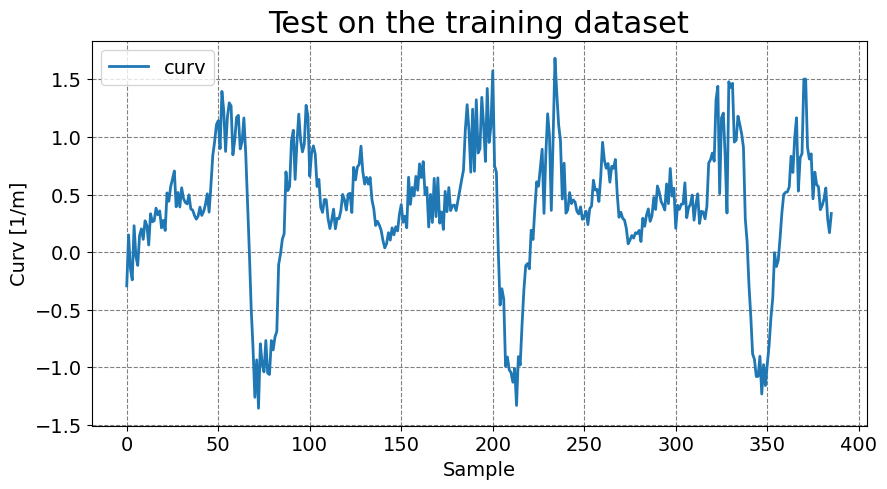

In [ ]:
# Load the dataset
data_folder_train = os.path.join(data_folder,'PurePursuit_Optitrack')
data_file = os.path.join(data_folder_train, 'Telemetry','PP_telemetry.csv')
df = pd.read_csv(data_file)

# Conversion in array
vx_erpm = df['Speed'].values
accy_g = df['accy'].values
accx_g = df['accx'].values
steering_angle = df['steering_angle'].values
yaw_rate = df['yaw_rate'].values

# Total number of samples
N = len(vx_erpm)
# Index for splitting
split_idx = int(0.7 * N)

# Dataset split into training set
vx_erpm_train = vx_erpm[:split_idx]
accy_g_train = accy_g[:split_idx]
accx_g_train = accx_g[:split_idx]
steering_angle_train = steering_angle[:split_idx]
yaw_rate_grads_train = yaw_rate[:split_idx]

# Dataset split into validation set
vx_erpm_valid = vx_erpm[split_idx:]
accy_g_valid = accy_g[split_idx:]
accx_g_valid = accx_g[split_idx:]
steering_angle_valid = steering_angle[split_idx:]
yaw_rate_grads_valid = yaw_rate[split_idx:]

# Conversion of vx from [erpm] into [m/s]
tao = 4244                                  # Conversion constant from [erpm] into [m/s]
vx_ms_train = vx_erpm_train/tao
vx_ms_valid = vx_erpm_valid/tao

# Conversion of accy [g] into [m/s^2]
accy_ms2_train = accy_g_train*9.81          # 1g = 9.81m/s^2
accy_ms2_valid = accy_g_valid*9.81

# Conversion of accx [g] into [m/s^2]
accx_ms2_train = accx_g_train*9.81          # 1g = 9.81m/s^2
accx_ms2_valid = accx_g_valid*9.81

# Conversion of yaw rate from [grad/s] into [rad/s]
yaw_rate_rads_train = yaw_rate_grads_train*np.pi/180   # 1grad = pi/180rad

# Evaluation of the curvature as curv = accy/(vx^2)
vx_safe_train = vx_ms_train.copy()
vx_safe_train[vx_safe_train < 0.1] = 1e-1        # to avoid division by zero
curv_train = accy_ms2_train/(vx_safe_train**2)

vx_safe_valid = vx_ms_valid.copy()
vx_safe_valid[vx_safe_valid < 0.1] = 1e-1        
curv_valid = accy_ms2_valid/(vx_safe_valid**2)      # provare con yawrate/vel


# Defintion of the training and validation dataset
training_set_new = {
    'steer_target': steering_angle_train[48:],
    'curv': curv_train[48:],
    'vx': vx_ms_train[48:],
    'accx': accx_ms2_train[48:],
    'accy': accy_ms2_train[48:]}

validation_set_new = {
    'steer_target': steering_angle_valid[:-45],
    'curv': curv_valid[:-45],
    'vx': vx_ms_valid[:-45],
    'accx': accx_ms2_valid[:-45],
    'accy': accy_ms2_valid[:-45]}

### Internal architecture

In [173]:
NeuObj.clearNames(['curv','vx','ax','ay','steer','curvature','k0_1','k0_2','kv_1','kv_2','ka_1','ka_2','steering'])

# -----------------------------------------------
# Neural model inputs and outputs
# -----------------------------------------------
curv  = Input('curv')                   # [1/m] path curvature
vx    = Input('vx')                     # [m/s] longitudinal velocity
ax    = Input('accx')                   # [m/s^2] longitudinal acceleration
ay    = Input('accy')                   # [m/s^2] lateral acceleration  
steer = Input('steer')                  # [rad] steering wheel angle 
steer_target = Input('steer_target')    # [rad] steering wheel angle --> this is used only as a training target

# Definition of constant parameters
L = 0.3302                              # [m] vehicle wheel base

# Extract the max values of vx from the training set
min_vx_train = np.min(np.abs(training_set_new['vx'])).item()
max_vx_train = np.max(np.abs(training_set_new['vx'])).item()

# -----------------------------------------------
# Hyperparameters
# -----------------------------------------------
# Window size for the inputs
num_samples_future_feedfw = 10   # number of future samples in the feedforward part of the model
num_samples_past_steer    = 10   # number of samples in the past for the steering wheel angle prediction

# Sample time for the input window (in seconds)
sample_time = 0.05   # this can be different from the sample time of the dataset (an internal interpolation is performed)

# Number of local models (aka channels) to model the lateral dynamics in different ranges of forward speed vx
num_channels_vx = 1
chan_centers_vx = list(np.linspace(min_vx_train, max_vx_train, num=num_channels_vx))  # centers of the channels

# -----------------------------------------------
# Understeering gradient correction
# -----------------------------------------------
# Custom function to model the understeering gradient correction
def understeer_corr(curv,vx,ax,ay,      # inputs
                    L,               # constants
                    k0_1,k0_2,kv_1,kv_2,ka_1,ka_2      # under-steering coeff. - learnable parameter
                    ):
    
    Kus_1 = k0_1 + kv_1*vx + ka_1*ax
    Kus_2 = k0_2 + kv_2*vx + ka_2*ax

    return (curv*L + Kus_1*abs(ay) + Kus_2*torch.pow(ay,2))


k0_1_guess = Parameter('k0_1',values=[[1e-5]])  # initial guess for the understeering k0_1 coeff. learnable parameter
k0_2_guess = Parameter('k0_2',values=[[1e-5]])  # initial guess for the understeering k0_2 coeff. learnable parameter
kv_1_guess = Parameter('kv_1',values=[[1e-5]])  # initial guess for the understeering kv_1 coeff. learnable parameter
kv_2_guess = Parameter('kv_2',values=[[1e-5]])  # initial guess for the understeering kv_2 coeff. learnable parameter
ka_1_guess = Parameter('ka_1',values=[[1e-5]])  # initial guess for the understeering ka_1 coeff. learnable parameter
ka_2_guess = Parameter('ka_2',values=[[1e-5]])  # initial guess for the understeering ka_2 coeff. learnable parameter

# Parametric function to model the understeering gradient correction
out_understeer_corr = ParamFun(understeer_corr,
                               parameters_and_constants=[L, k0_1_guess,k0_2_guess,kv_1_guess,kv_2_guess,ka_1_guess,ka_2_guess],        #learnable parameters and constant parameters
                               )(curv.sw([0,num_samples_future_feedfw]),
                                 vx.sw([0,num_samples_future_feedfw]),
                                 ax.sw([0,num_samples_future_feedfw]),
                                 ay.sw([0,num_samples_future_feedfw]))
                              

# -----------------------------------------------
# Local models to capture the pure lateral transient vehicle dynamics
# in different ranges of forward speed vx
# -----------------------------------------------

# Activation functions for the local models
activ_fcns_vx = Fuzzify(centers=chan_centers_vx, functions='Triangular')(vx.sw([0,num_samples_future_feedfw]))

# Define the local models
local_model_lat_dyna = LocalModel(output_function=lambda: Fir(W_init = 'init_exp',
                                  W_init_params={'size_index':0, 'max_value':0.0001,
                                                 'lambda':5, 'monotonicity':'decreasing'}))
out_local_model_lat_dyna = local_model_lat_dyna(out_understeer_corr, activ_fcns_vx)


out_no_arx   = Output('steering_angle', out_local_model_lat_dyna)            # output of the feed-forward model (no auto-regression)    


### nnodely definitions

In [174]:
# Create a nnodely model
path_folder_no_arx   = os.path.join(os.getcwd(),'trained_models','steer_controller_base_extension2')    # folder to save the model without auto-regression
steer_controller_no_arx_reduced   = nnodely(visualizer='Standard',seed=12,workspace=path_folder_no_arx,save_history=False)  #visualizer=MPLVisualizer()
  
# Add the neural model to the nnodely structure and neuralization of the model
steer_controller_no_arx_reduced.addModel('steer_ctrl',[out_no_arx])
steer_controller_no_arx_reduced.addMinimize('steer_error', 
                                    steer_target.next(),  # next means the first value in the "future"
                                    out_no_arx, 
                                    loss_function='rmse')

#### Create the model with no auto-regression

In [175]:
steer_controller_no_arx_reduced.neuralizeModel()  # neuralize the model with the chosen sample time

================================ nnodely Model =================================
{'Constants': {'FParamFun12L': {'dim': 1, 'values': [0.3301999866962433]}},
 'Functions': {'FFuzzify14': {'centers': [1.440181717988441],
                              'dim_out': {'dim': 1},
                              'functions': 'Triangular',
                              'names': 'Triangular'},
               'FParamFun12': {'code': 'def '
                                       'understeer_corr(curv,vx,ax,ay,      # '
                                       'inputs\n'
                                       '                    L,               # '
                                       'constants\n'
                                       '                    '
                                       'k0_1,k0_2,kv_1,kv_2,ka_1,ka_2      # '
                                       'under-steering coeff. - learnable '
                                       'parameter\n'
                                     

## Training and validation datasets

In [176]:
# Pass the training and validation datasets to the nnodely structure
data_struct_no_arx = ['steer_target','curv','vx','accx','accy']  
steer_controller_no_arx_reduced.loadData(name='training_set', source=training_set_new, format=data_struct_no_arx)
steer_controller_no_arx_reduced.loadData(name='validation_set', source=validation_set_new, format=data_struct_no_arx)

============================ nnodely Model Dataset =============================
Dataset Name:                 training_set
Number of files:              1
Total number of samples:      377
Shape of vx:                  (377, 10, 1)
Shape of accy:                (377, 10, 1)
Shape of accx:                (377, 10, 1)
Shape of curv:                (377, 10, 1)
Shape of steer_target:        (377, 1, 1)
============================ nnodely Model Dataset =============================
Dataset Name:                 validation_set
Number of files:              1
Total number of samples:      133
Shape of vx:                  (133, 10, 1)
Shape of accy:                (133, 10, 1)
Shape of accx:                (133, 10, 1)
Shape of curv:                (133, 10, 1)
Shape of steer_target:        (133, 1, 1)


## Training

### Train the feed-forward NN (no auto-regression) in open-loop 

In [177]:
num_epochs = 10000
batch_size = 150
learn_rate = 1e-4  # learning rate
early_stop_patience = 1000  # n. of epochs without improvement to stop the training
training_pars = {'num_of_epochs':num_epochs, 
                 'val_batch_size':batch_size, 
                 'train_batch_size':batch_size, 
                 'lr':learn_rate}

flag_train_now = 1  # flag to train the model now or load a pre-trained model
if flag_train_now:
  train_result_open_loop = steer_controller_no_arx_reduced.trainModel(train_dataset='training_set', validation_dataset='validation_set', 
                                                                      training_params=training_pars, optimizer='Adam', shuffle_data=True,
                                                                      early_stopping=earlystopping.early_stop_patience,  
                                                                      early_stopping_params={'patience':early_stop_patience,
                                                                      'error':'steer_error'})  
else:
  # Load the trained model
  steer_controller_no_arx_reduced.loadModel()  

======================== nnodely Model Train Parameters ========================
models:                       ['steer_ctrl']
num of epochs:                10000
update per epochs:            2.5133333333333336
└>(n_samples-batch_size)/batch_size+1
shuffle data:                 True
early stopping:               early_stop_patience
early stopping params:        {'error': 'steer_error', 'patience': 1000}
train dataset:                training_set
	- num of samples:            377
	- batch size:                150
	- unused samples:            -5.684341886080802e-14
	  └>n_samples-update_per_epochs*batch_size
val dataset:                  validation_set
val {batch size, samples}:    {133, 133}
minimizers:                   {'steer_error': {'A': 'SamplePart307',
                                               'B': 'steering_angle',
                                               'loss': 'rmse'}}
optimizer:                    Adam
optimizer defaults:           {'lr': 0.0001}
optimizer params

In [178]:
# Print the trained NN parameters
steer_controller_no_arx_reduced.neuralizeModel()

if flag_train_now:
  # Save the trained model
  steer_controller_no_arx_reduced.saveModel()

# Export the trained model to a .onnx file
#steer_controller_no_arx_reduced.exportONNX(inputs_order=['curv', 'vx'], outputs_order=['steering_angle'], name='steer_controller_base', model_folder='trained_models')

================================ nnodely Model =================================
{'Constants': {'FParamFun12L': {'dim': 1, 'values': [0.3301999866962433]}},
 'Functions': {'FFuzzify14': {'centers': [1.440181717988441],
                              'dim_out': {'dim': 1},
                              'functions': 'Triangular',
                              'names': 'Triangular'},
               'FParamFun12': {'code': 'def '
                                       'understeer_corr(curv,vx,ax,ay,      # '
                                       'inputs\n'
                                       '                    L,               # '
                                       'constants\n'
                                       '                    '
                                       'k0_1,k0_2,kv_1,kv_2,ka_1,ka_2      # '
                                       'under-steering coeff. - learnable '
                                       'parameter\n'
                                     

#### Test on the training dataset

MSE on the test set:  [0.00114614]  rad^2


c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:300: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates._SwitchableDateConverter)
c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:303: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.DateConverter)
c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:306: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.ConciseDateConverter)
c:\Users\A

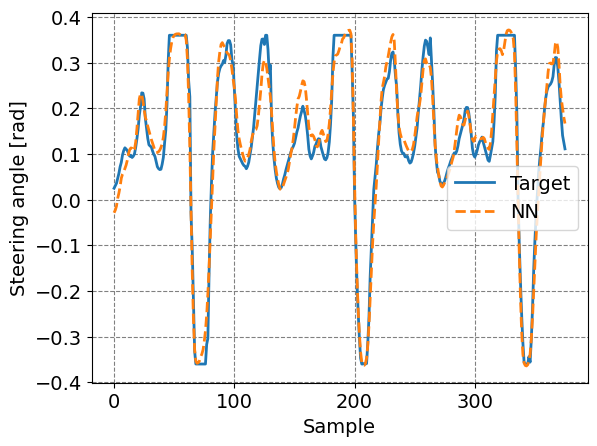

In [ ]:
# Test on a new dataset
num_samples_use = np.size(training_set_new['steer_target'])-num_samples_future_feedfw  # number of samples to use for the test
samples_test_set_train = steer_controller_no_arx_reduced.getSamples('training_set', index=0, window=num_samples_use) 
out_nn_test_set_train  = steer_controller_no_arx_reduced(samples_test_set_train, sampled=True)
out_nn_test_set_extract_train = np.asarray(out_nn_test_set_train['steering_angle'])
out_nn_test_set_extract_train = clip_sat(out_nn_test_set_extract_train, -0.36, 0.36, 0.1)

# Save of the NN prediction to a csv file
#df = pd.DataFrame(out_nn_test_set_extract, columns=['Steering_angle'])
#df.to_csv("Autonomous_antiorario_Steering_angle_prediction_ControlLateralBase.csv", index=False)

# Extract the samples
samples_test_set_extract_train = np.zeros((len(samples_test_set_train['steer_target']),1))
for i in range(0,len(samples_test_set_extract_train)):
  samples_test_set_extract_train[i] = samples_test_set_train['steer_target'][i]

# Compute the MSE on the test set
mse_calc = 0
for i in range(0,len(samples_test_set_extract_train)):
  mse_calc = mse_calc + (samples_test_set_extract_train[i] - out_nn_test_set_extract_train[i])**2 
mse_calc = mse_calc/len(samples_test_set_extract_train)
print('MSE on the test set: ', mse_calc, ' rad^2')

flag_plot_results = True
if flag_plot_results:
  # plot the results
  plt.figure()
  plt.plot(samples_test_set_extract_train,label='Target',linewidth=2)
  plt.plot(out_nn_test_set_extract_train,label='NN',linestyle='--',linewidth=2)
  plt.xlabel('Sample')
  plt.ylabel('Steering angle [rad]')
  plt.legend()
  plt.grid()
  plt.show()  

#### Test on the validation dataset

MSE on the test set:  [0.00122288]  rad^2


c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:300: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates._SwitchableDateConverter)
c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:303: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.DateConverter)
c:\Users\ASUS\anaconda3\envs\mio_env_nuovo\Lib\site-packages\mpld3\mplexporter\utils.py:306: MatplotlibDeprecationWarning: The converter attribute was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use get_converter and set_converter methods instead.
  isinstance(axis.converter, matplotlib.dates.ConciseDateConverter)
c:\Users\A

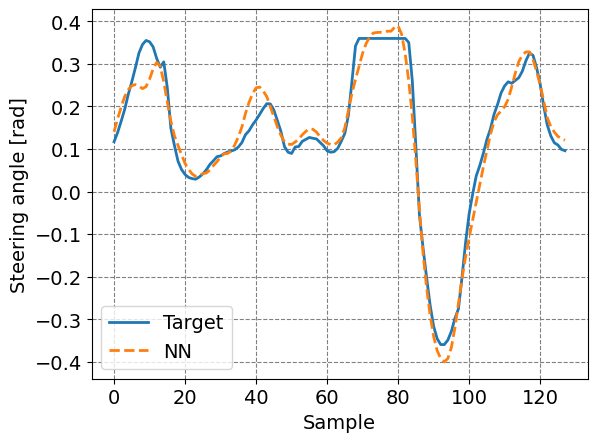

In [ ]:
# Test on a new dataset
num_samples_use = np.size(validation_set_new['steer_target'])-num_samples_future_feedfw  # number of samples to use for the test
samples_test_set_valid = steer_controller_no_arx_reduced.getSamples('validation_set', index=0, window=num_samples_use)
out_nn_test_set_valid  = steer_controller_no_arx_reduced(samples_test_set_valid, sampled=True)
out_nn_test_set_extract_valid = np.asarray(out_nn_test_set_valid['steering_angle'])
out_nn_test_set_extract_train = clip_sat(out_nn_test_set_extract_train, -0.36, 0.36, 0.1)


# Extract the samples
samples_test_set_extract_valid = np.zeros((len(samples_test_set_valid['steer_target']),1))
for i in range(0,len(samples_test_set_extract_valid)):
  samples_test_set_extract_valid[i] = samples_test_set_valid['steer_target'][i]

# Compute the MSE on the test set
mse_calc = 0
for i in range(0,len(samples_test_set_extract_valid)):
  mse_calc = mse_calc + (samples_test_set_extract_valid[i] - out_nn_test_set_extract_valid[i])**2 
mse_calc = mse_calc/len(samples_test_set_extract_valid)
print('MSE on the test set: ', mse_calc, ' rad^2')

flag_plot_results = True
if flag_plot_results:
  # plot the results
  plt.figure()
  plt.plot(samples_test_set_extract_valid,label='Target',linewidth=2)
  plt.plot(out_nn_test_set_extract_valid,label='NN',linestyle='--',linewidth=2)
  plt.xlabel('Sample')
  plt.ylabel('Steering angle [rad]')
  plt.legend()
  plt.grid()
  plt.show()